# EDA Goodreads — Fantasy & Paranormal

EDA completo de nivel Senior Data Scientist para la categoría Fantasy & Paranormal. Explota estructuras anidadas (`authors`, `popular_shelves`, `series`), cruza books con interactions, y entrega insights específicos del género.

No depende de `process_goodreads` ni de una CLI previa.

In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import clean_books, clean_interactions
from src.utils.eda import (
    build_eda_profile,
    author_profile,
    shelves_profile,
    series_profile,
    engagement_profile,
    reading_duration_profile,
    user_rating_behavior,
    isbn_quality_profile,
    platform_growth_profile,
)

sns.set_theme(style='whitegrid')

## 1. Inputs, carga y limpieza base

Se cargan muestras controladas desde los `.json.gz` crudos. Las versiones limpias (`books_clean`, `interactions_clean`) se construyen una vez aquí y se reusan en todo el notebook.

In [2]:
CATEGORY = 'fantasy_paranormal'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 50_000
INTERACTIONS_SAMPLE = 250_000

print(cfg.books_file)
print(cfg.interactions_file)

/home/chris/Documentos/u/BigBook/data/raw/goodreads_books_fantasy_paranormal.json.gz
/home/chris/Documentos/u/BigBook/data/raw/goodreads_interactions_fantasy_paranormal.json.gz


In [3]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

books_clean = clean_books(books_raw)
interactions_clean = clean_interactions(interactions_raw)

print(f'books_raw:         {books_raw.shape}')
print(f'books_clean:       {books_clean.shape}')
print(f'interactions_raw:  {interactions_raw.shape}')
print(f'interactions_clean:{interactions_clean.shape}')

books_raw:         (50000, 29)
books_clean:       (50000, 40)
interactions_raw:  (250000, 10)
interactions_clean:(250000, 14)


## 2. Perfilamiento general

Se calculan esquema, nulos, duplicados, perfiles numéricos, outliers, categóricas, ratings y temporalidad.

In [4]:
artifacts, summary = build_eda_profile(
    books_raw=books_raw,
    interactions_raw=interactions_raw,
    book_numeric_columns=BOOK_NUMERIC_COLUMNS,
    interaction_numeric_columns=['rating'],
)
summary

{'books_sample_rows': 50000,
 'interactions_sample_rows': 250000,
 'temporal_profile': {'publication_year': {'non_null': 37859,
   'min': 12,
   'max': 29017,
   'before_1450': 20,
   'after_2026': 8},
  'date_added': {'non_null_raw': 250000,
   'parsed': 250000,
   'invalid_or_missing': 0,
   'min': '2006-08-20T02:10:46+00:00',
   'max': '2017-10-26T23:43:05+00:00'},
  'date_updated': {'non_null_raw': 250000,
   'parsed': 250000,
   'invalid_or_missing': 0,
   'min': '2006-08-29T18:44:38+00:00',
   'max': '2017-10-30T21:16:25+00:00'},
  'read_at': {'non_null_raw': 54854,
   'parsed': 54854,
   'invalid_or_missing': 195146,
   'min': '1967-01-01T08:00:00+00:00',
   'max': '2017-10-30T11:03:51+00:00'},
  'started_at': {'non_null_raw': 42085,
   'parsed': 42085,
   'invalid_or_missing': 207915,
   'min': '1993-01-01T08:00:00+00:00',
   'max': '2017-10-30T13:28:11+00:00'}},
 'rating_profile': {'average_rating': {'count': 50000,
   'min': 0.0,
   'mean': 3.9427760000000003,
   'max': 5.0,


## 3. Esquema y nulos

Goodreads mezcla strings vacíos, nulos reales y campos numéricos codificados como texto. Los campos anidados (`authors`, `popular_shelves`, `series`) aparecen como `object` y requieren flatten explícito.

In [5]:
display(artifacts['books_schema'])
display(artifacts['interactions_schema'])
display(artifacts['books_missing'].head(20))
display(artifacts['interactions_missing'].head(20))

,column,dtype,non_null,null,unique_sample
0,isbn,str,50000,0,"[, 1934876569, ]"
1,text_reviews_count,str,50000,0,"[7, 6, 60]"
2,series,object,50000,0,"[['189911'], ['151854'], ['1052227']]"
3,country_code,str,50000,0,"[US, US, US]"
4,language_code,str,50000,0,"[eng, , eng]"
5,popular_shelves,object,50000,0,"[[{'count': '58', 'name': 'to-read'}, {'count'..."
6,asin,str,50000,0,"[B00071IKUY, , B01NCIKAQX]"
7,is_ebook,str,50000,0,"[false, false, true]"
8,average_rating,str,50000,0,"[4.03, 4.22, 4.33]"
9,kindle_asin,str,50000,0,"[, , B01NCIKAQX]"


,column,dtype,non_null,null,unique_sample
0,user_id,str,250000,0,"[8842281e1d1347389f2ab93d60773d4d, 8842281e1d1..."
1,book_id,str,250000,0,"[19161852, 18245960, 32075825]"
2,review_id,str,250000,0,"[4443cb6883624c3772625ef5b7b4e138, dfdbb7b0eb5..."
3,is_read,bool,250000,0,"[False, True, False]"
4,rating,int64,250000,0,"[0, 5, 0]"
5,review_text_incomplete,str,250000,0,"[, This is a special book. It started slow for..."
6,date_added,str,250000,0,"[Fri Sep 08 10:44:24 -0700 2017, Sun Jul 30 07..."
7,date_updated,str,250000,0,"[Fri Sep 08 10:44:24 -0700 2017, Wed Aug 30 00..."
8,read_at,str,250000,0,"[, Sat Aug 26 12:05:52 -0700 2017, ]"
9,started_at,str,250000,0,"[, Tue Aug 15 13:23:18 -0700 2017, ]"


,column,dtype,missing,empty_strings,missing_pct
0,edition_information,str,0,44873,0.0
1,asin,str,0,36281,0.0
2,kindle_asin,str,0,25779,0.0
3,isbn,str,0,24974,0.0
4,isbn13,str,0,19308,0.0
5,publication_day,str,0,18906,0.0
6,publication_month,str,0,15886,0.0
7,num_pages,str,0,15821,0.0
8,publisher,str,0,14111,0.0
9,language_code,str,0,13670,0.0


,column,dtype,missing,empty_strings,missing_pct
0,review_text_incomplete,str,0,234513,0.0
1,started_at,str,0,207915,0.0
2,read_at,str,0,195146,0.0
3,user_id,str,0,0,0.0
4,book_id,str,0,0,0.0
5,review_id,str,0,0,0.0
6,is_read,bool,0,0,0.0
7,rating,int64,0,0,0.0
8,date_added,str,0,0,0.0
9,date_updated,str,0,0,0.0


## 4. Análisis de Autores

`authors` es una lista de objetos `{author_id, role}`. Cada libro puede tener múltiples entradas: autores principales, traductores, ilustradores. Si se usa `primary_author_id` como feature sin filtrar el rol, los traductores contaminan la señal de autor.

In [6]:
author_artifacts = author_profile(books_raw)
display(author_artifacts['author_count_dist'])
display(author_artifacts['role_dist'])

,author_count_bin,books
0,1,39335
1,2,7923
2,3+,2742


,role,count
0,<empty>,48987
1,Editor,598
2,editor,36
3,Pseudonym,36
4,Editor / Contributor,25
...,...,...
98,Compiler,1
99,Seleccion,1
100,Editor/Introduction,1
101,writer,1


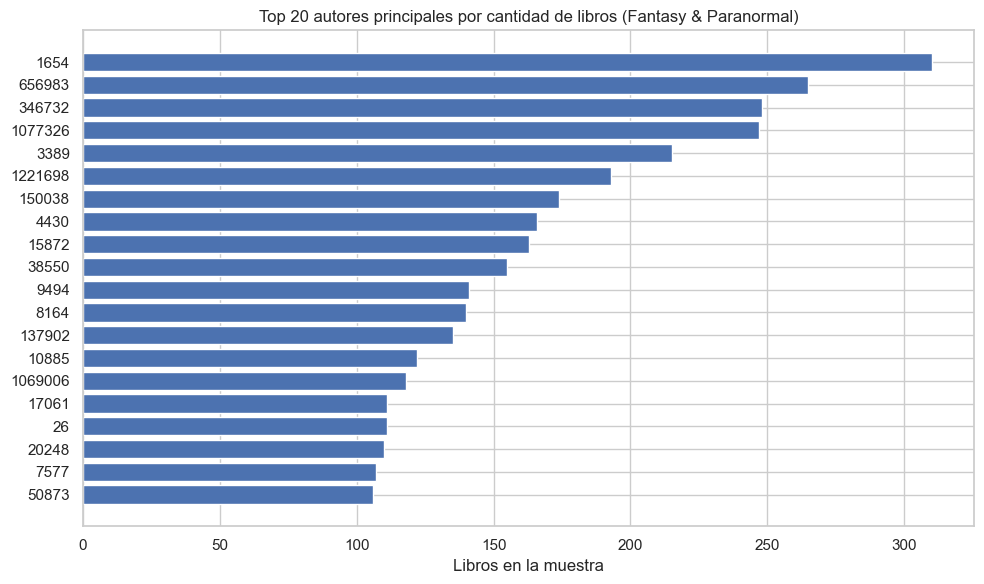


Autores únicos (primary_author_id): 30
Libros sin autor identificado:       0


In [7]:
top_authors = author_artifacts['top_authors'].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_authors['author_id'].astype(str)[::-1], top_authors['book_count'][::-1])
ax.set_xlabel('Libros en la muestra')
ax.set_title('Top 20 autores principales por cantidad de libros (Fantasy & Paranormal)')
plt.tight_layout()
plt.show()

print(f"\nAutores únicos (primary_author_id): {author_artifacts['top_authors']['author_id'].nunique()}")
print(f"Libros sin autor identificado:       {author_artifacts['author_count_dist'].set_index('author_count_bin').loc['0', 'books'] if '0' in author_artifacts['author_count_dist']['author_count_bin'].values else 0}")

## 5. Análisis de Popular Shelves / Géneros

`popular_shelves` es taxonomía de usuarios: cada libro tiene una lista de `{name, count}` que representa cuántos usuarios pusieron el libro en ese shelf. Contiene tanto señales de género (`fantasy`, `paranormal`, `urban-fantasy`) como de estado de lectura (`to-read`, `currently-reading`, `read`). El campo `to-read` es un proxy de demanda/hype, no de género.

In [8]:
shelf_artifacts = shelves_profile(books_raw, top_n=30)

print('=== Distribución de shelf_count por libro ===')
display(shelf_artifacts['shelf_count_dist'].head(15))

print('\n=== to-read como indicador de demanda ===')
display(shelf_artifacts['to_read_dist'])

=== Distribución de shelf_count por libro ===


,shelf_count,books
0,1,2
1,2,3
2,3,24
3,4,59
4,5,74
5,6,114
6,7,136
7,8,166
8,9,186
9,10,236



=== to-read como indicador de demanda ===


,stat,value
0,count,49647.000000
1,mean,6202.335891
2,p25,76.000000
3,median,388.000000
4,p75,1951.500000
5,p95,21515.000000
6,max,543151.000000


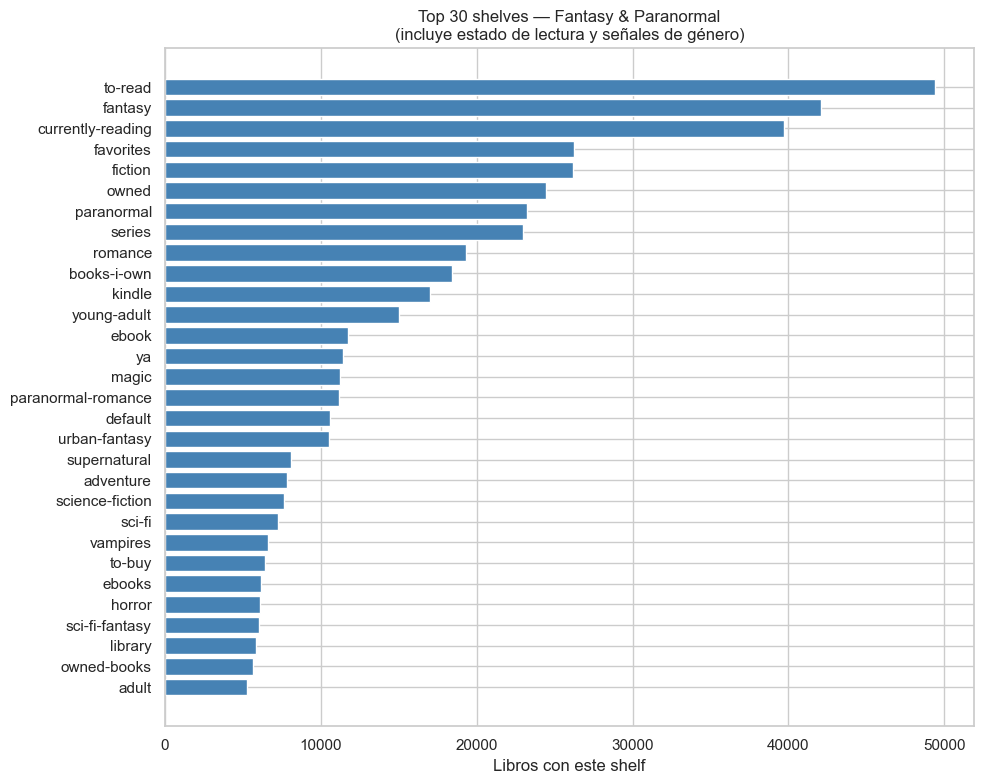

In [9]:
top30 = shelf_artifacts['top_shelf_names'].head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30['shelf_name'][::-1], top30['book_count'][::-1], color='steelblue')
ax.set_xlabel('Libros con este shelf')
ax.set_title('Top 30 shelves — Fantasy & Paranormal\n(incluye estado de lectura y señales de género)')
plt.tight_layout()
plt.show()

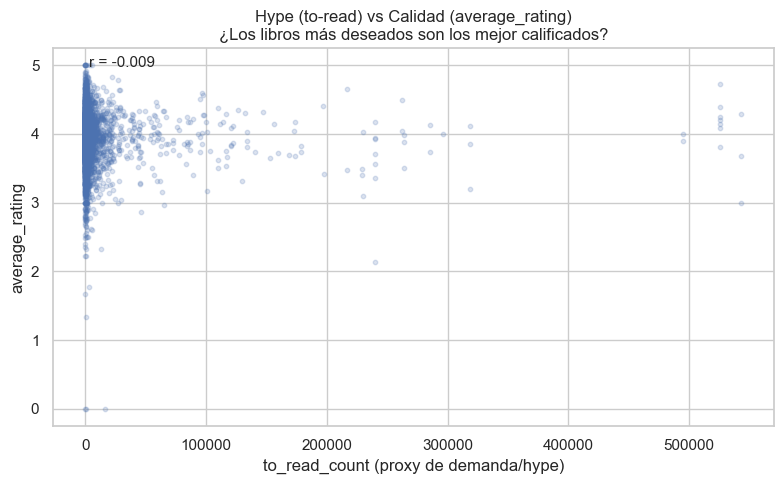


=== Top 20 co-ocurrencias de shelves (pares de géneros más frecuentes) ===


,shelf_a,shelf_b,cooccurrence
0,fantasy,to-read,29171
1,currently-reading,to-read,24612
2,currently-reading,fantasy,15116
3,paranormal,to-read,12679
4,to-read,young-adult,8914
5,fiction,to-read,8097
6,favorites,to-read,8019
7,fantasy,young-adult,7472
8,fantasy,fiction,6907
9,fantasy,favorites,6696


In [10]:
from src.utils.cleaning import _shelves_summary

shelf_flat = books_raw['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=20)).apply(pd.Series)
combined = books_clean.copy()
combined['to_read_count'] = shelf_flat['to_read_count'].values

sample = combined[['to_read_count', 'average_rating']].dropna().sample(min(5000, len(combined)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['to_read_count'], sample['average_rating'], alpha=0.2, s=10)
ax.set_xlabel('to_read_count (proxy de demanda/hype)')
ax.set_ylabel('average_rating')
ax.set_title('Hype (to-read) vs Calidad (average_rating)\n¿Los libros más deseados son los mejor calificados?')
corr = sample[['to_read_count', 'average_rating']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.show()

print('\n=== Top 20 co-ocurrencias de shelves (pares de géneros más frecuentes) ===')
display(shelf_artifacts['cooccurrence_sample'].head(20))

## 6. Análisis de Series

Fantasy es el género con mayor tasa de libros en serie. El campo `series` contiene IDs de series a las que pertenece el libro. Los libros en serie tienden a tener más ratings (el lector ya está comprometido con la saga) y exhiben sesgo de supervivencia: nadie continúa una mala serie.

In [11]:
series_artifacts = series_profile(books_raw)

display(series_artifacts['standalone_vs_series'])
display(series_artifacts['series_length_dist'])

s = series_artifacts['summary']
print(f"\n{s['pct_in_series']:.1%} de libros en la muestra pertenecen a al menos una serie")
print(f"Longitud mediana de serie (para libros en serie): {s['median_length']:.1f} IDs de serie")

,in_series,count,pct
0,False,13770,0.2754
1,True,36230,0.7246


,series_length,books
0,0,13770
1,1,31883
2,2,3289
3,3,674
4,4,384



72.5% de libros en la muestra pertenecen a al menos una serie
Longitud mediana de serie (para libros en serie): 1.0 IDs de serie


Rating por tipo de libro:


,count,mean,50%,std
in_series,,,,
False,13770.0,3.822272,3.84,0.422465
True,36230.0,3.988576,4.00,0.325970


/tmp/ipykernel_128292/1092379009.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Standalone', 'En serie'])


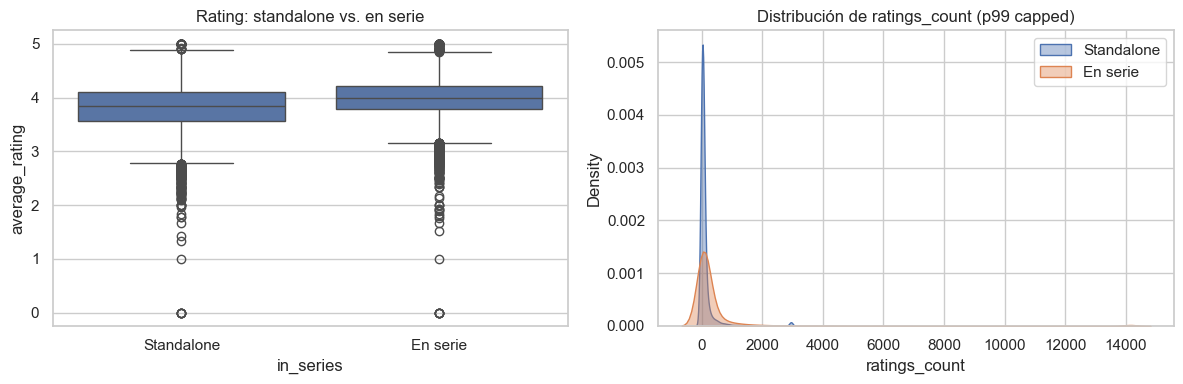

In [12]:
books_clean_s = books_clean.copy()
books_clean_s['in_series'] = books_clean_s['series_count'].gt(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

series_rating = books_clean_s.groupby('in_series')['average_rating'].describe()[['count','mean','50%','std']]
print('Rating por tipo de libro:')
display(series_rating)

sns.boxplot(data=books_clean_s.dropna(subset=['average_rating']),
            x='in_series', y='average_rating', ax=axes[0])
axes[0].set_title('Rating: standalone vs. en serie')
axes[0].set_xticklabels(['Standalone', 'En serie'])

for label, grp in books_clean_s.groupby('in_series'):
    rc = pd.to_numeric(grp['ratings_count'], errors='coerce').dropna()
    rc_clip = rc.clip(upper=rc.quantile(0.99))
    sns.kdeplot(rc_clip, ax=axes[1], label='En serie' if label else 'Standalone', fill=True, alpha=0.4)
axes[1].set_title('Distribución de ratings_count (p99 capped)')
axes[1].set_xlabel('ratings_count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Ratings

Se analiza `average_rating` a nivel libro y `rating` a nivel interacción. `rating = 0` es la convención de Goodreads para ausencia de rating explícito: el usuario marcó el libro sin calificarlo.

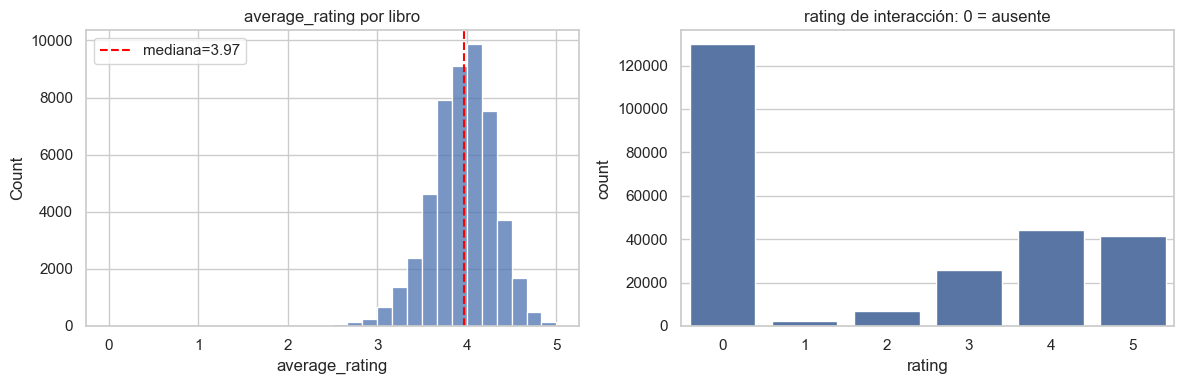

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(books_clean['average_rating'].dropna(), bins=30, ax=axes[0])
axes[0].set_title('average_rating por libro')
axes[0].axvline(books_clean['average_rating'].median(), color='red', linestyle='--', label=f"mediana={books_clean['average_rating'].median():.2f}")
axes[0].legend()

sns.countplot(data=interactions_clean, x='rating', ax=axes[1])
axes[1].set_title('rating de interacción: 0 = ausente')

plt.tight_layout()
plt.show()

## 8. Comportamiento de Usuarios en Interacciones

Las interacciones no son homogéneas: muchos usuarios solo agregan libros a su shelf sin leerlos, otros leen sin calificar. Esta sección cuantifica esos patrones y analiza cuánto tiempo tardan en leer un libro.

In [15]:
duration_artifacts = reading_duration_profile(interactions_clean)

print(f"Interacciones con dato de duración: {duration_artifacts['pct_with_duration']:.1%}")
print(f"(requiere both started_at y read_at presentes)")
display(duration_artifacts['duration_stats'])

Interacciones con dato de duración: 15.1%
(requiere both started_at y read_at presentes)


,stat,value
0,count,37649.000000
1,p25,1.168218
2,median,4.000000
3,mean,21.104825
4,p75,11.174780
5,p95,73.084067


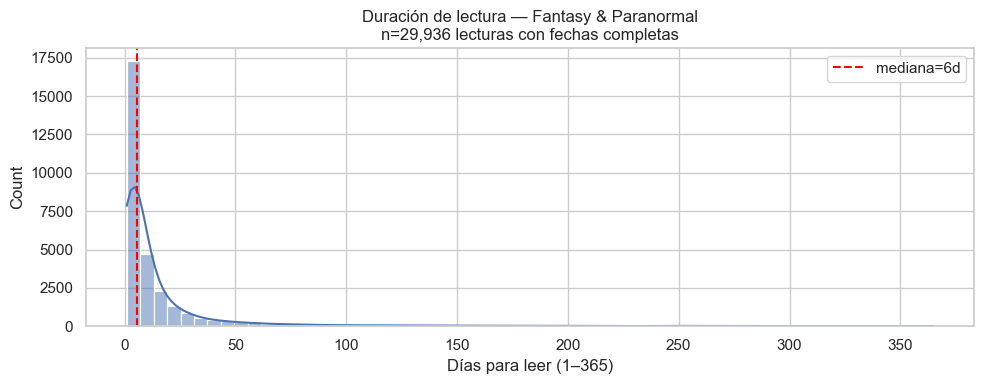

In [16]:
dur = duration_artifacts['duration_distribution']
if len(dur) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(dur, bins=60, ax=ax, kde=True)
    ax.set_xlabel('Días para leer (1–365)')
    ax.set_title(f'Duración de lectura — Fantasy & Paranormal\nn={len(dur):,} lecturas con fechas completas')
    ax.axvline(dur.median(), color='red', linestyle='--', label=f'mediana={dur.median():.0f}d')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [17]:
user_artifacts = user_rating_behavior(interactions_clean)

print('=== Ratings por usuario ===')
display(user_artifacts['ratings_per_user'])

print('\n=== Clasificación de usuarios (≥3 ratings) ===')
display(user_artifacts['user_type_dist'])

=== Ratings por usuario ===


,stat,value
0,users,2112.000000
1,p25,9.000000
2,median,26.000000
3,mean,56.960701
4,p75,67.000000
5,p95,211.000000
6,max,859.000000



=== Clasificación de usuarios (≥3 ratings) ===


,user_type,count,pct
0,generous,1018,0.5375
1,average,866,0.4572
2,critical,10,0.0053


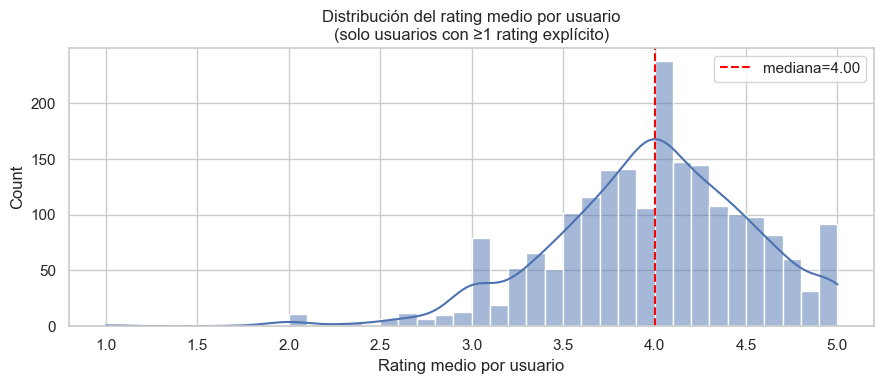

In [18]:
mean_ratings = user_artifacts['mean_rating_per_user']
if len(mean_ratings) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(mean_ratings, bins=40, ax=ax, kde=True)
    ax.set_xlabel('Rating medio por usuario')
    ax.set_title('Distribución del rating medio por usuario\n(solo usuarios con ≥1 rating explícito)')
    ax.axvline(mean_ratings.median(), color='red', linestyle='--', label=f'mediana={mean_ratings.median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

,year,new_interactions,pct_with_rating,cumulative_interactions
0,2006,13,1.0000,13
1,2007,547,0.9269,560
2,2008,6467,0.7475,7027
3,2009,4061,0.5311,11088
4,2010,3181,0.6080,14269
5,2011,3383,0.6231,17652
6,2012,69757,0.6535,87409
7,2013,44261,0.4400,131670
8,2014,34090,0.4128,165760
9,2015,31899,0.3986,197659


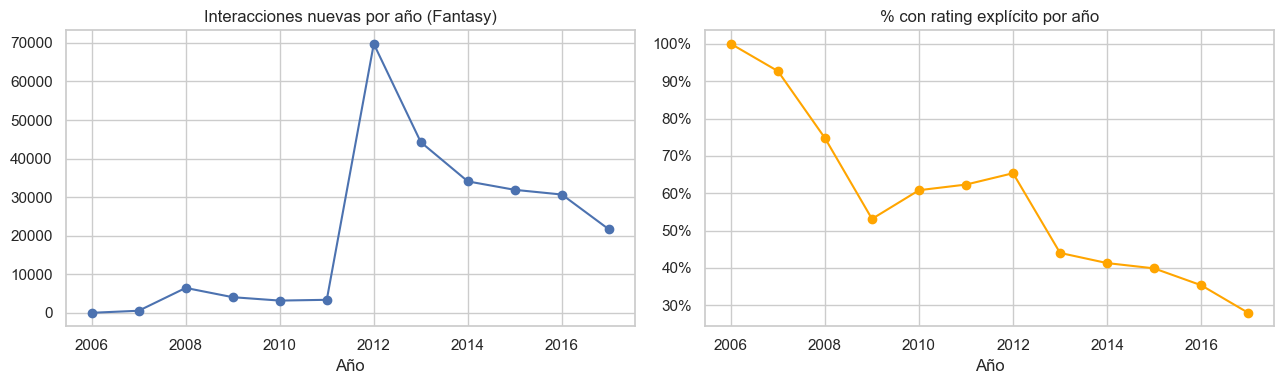

In [19]:
growth = platform_growth_profile(interactions_clean)
display(growth)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
growth.set_index('year')['new_interactions'].plot(ax=axes[0], marker='o')
axes[0].set_title('Interacciones nuevas por año (Fantasy)')
axes[0].set_xlabel('Año')

growth.set_index('year')['pct_with_rating'].plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('% con rating explícito por año')
axes[1].set_xlabel('Año')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## 9. JOIN Cross-Dataset: Books × Interactions

Se cruzan los datasets para responder preguntas que requieren ambas perspectivas:
- ¿El `average_rating` de Goodreads (calculado sobre todos los usuarios de la plataforma) concuerda con el rating promedio de la **muestra**?
- ¿Qué fracción de libros tiene muy pocas interacciones? (cold start para recommender)
- ¿Cómo se distribuye la popularidad? (ley de potencia)

In [20]:
eng_artifacts = engagement_profile(books_clean, interactions_clean)

print('=== Modos de engagement (clasificación de interacciones) ===')
display(eng_artifacts['engagement_modes'])

print('\n=== Cold start: libros con pocas interacciones en la muestra ===')
display(eng_artifacts['cold_start'])

print('\n=== Tasa de review por formato ===')
display(eng_artifacts['review_rate_by_format'])

=== Modos de engagement (clasificación de interacciones) ===


,mode,count,pct
0,shelf_only,121964,0.4879
1,rated,105298,0.4212
2,reviewed,15003,0.0600
3,read_no_rating,7735,0.0309



=== Cold start: libros con pocas interacciones en la muestra ===


,min_interactions,books_below,pct_below
0,1,39258,0.7852
1,5,48246,0.9649
2,10,49129,0.9826
3,25,49685,0.9937
4,50,49872,0.9974



=== Tasa de review por formato ===


,format,review_rate
21,Online,1.0000
34,nook book,0.5000
0,Audible Audio,0.3200
20,Nook,0.2500
1,Audio,0.1250
16,Library Binding,0.1053
4,Audiobook,0.0980
9,Broschiert,0.0909
30,ebook,0.0784
14,Kindle Edition,0.0772


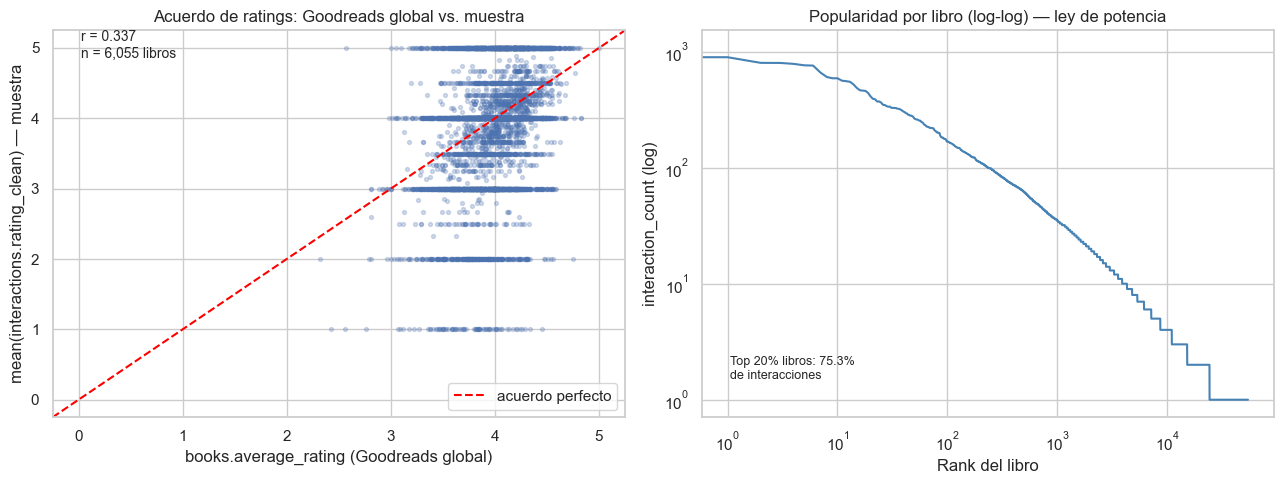

In [21]:
ra = eng_artifacts['rating_agreement'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ra['average_rating'], ra['mean_user_rating'], alpha=0.25, s=8)
axes[0].axline((0, 0), slope=1, color='red', linestyle='--', label='acuerdo perfecto')
axes[0].set_xlabel('books.average_rating (Goodreads global)')
axes[0].set_ylabel('mean(interactions.rating_clean) — muestra')
axes[0].set_title('Acuerdo de ratings: Goodreads global vs. muestra')
if len(ra) > 1:
    r = ra[['average_rating', 'mean_user_rating']].corr().iloc[0, 1]
    axes[0].text(0.05, 0.93, f'r = {r:.3f}\nn = {len(ra):,} libros', transform=axes[0].transAxes, fontsize=10)
axes[0].legend()

pop = eng_artifacts['popularity_distribution']['interaction_count'].sort_values(ascending=False).reset_index(drop=True)
if len(pop) > 0:
    pop.plot(ax=axes[1], logy=True, logx=True, color='steelblue')
    axes[1].set_title('Popularidad por libro (log-log) — ley de potencia')
    axes[1].set_xlabel('Rank del libro')
    axes[1].set_ylabel('interaction_count (log)')
    top20 = pop.iloc[:int(len(pop) * 0.2)].sum() / pop.sum() if len(pop) > 5 else None
    if top20 is not None:
        axes[1].text(0.05, 0.1, f'Top 20% libros: {top20:.1%}\nde interacciones', transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
plt.show()

## 10. Temporalidad

Se revisan años de publicación y fechas de interacción. Los años imposibles (`< 1450` o `> 2026`) se preservan como `publication_year` y se limpian en `publication_year_clean`.

In [22]:
summary['temporal_profile']

{'publication_year': {'non_null': 37859,
  'min': 12,
  'max': 29017,
  'before_1450': 20,
  'after_2026': 8},
 'date_added': {'non_null_raw': 250000,
  'parsed': 250000,
  'invalid_or_missing': 0,
  'min': '2006-08-20T02:10:46+00:00',
  'max': '2017-10-26T23:43:05+00:00'},
 'date_updated': {'non_null_raw': 250000,
  'parsed': 250000,
  'invalid_or_missing': 0,
  'min': '2006-08-29T18:44:38+00:00',
  'max': '2017-10-30T21:16:25+00:00'},
 'read_at': {'non_null_raw': 54854,
  'parsed': 54854,
  'invalid_or_missing': 195146,
  'min': '1967-01-01T08:00:00+00:00',
  'max': '2017-10-30T11:03:51+00:00'},
 'started_at': {'non_null_raw': 42085,
  'parsed': 42085,
  'invalid_or_missing': 207915,
  'min': '1993-01-01T08:00:00+00:00',
  'max': '2017-10-30T13:28:11+00:00'}}

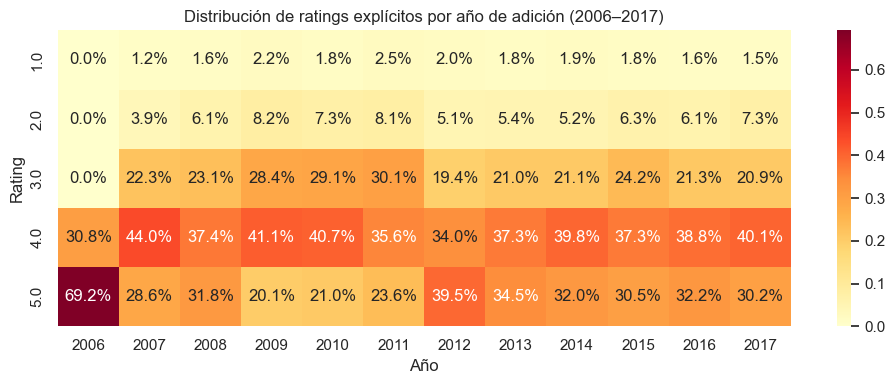

In [24]:
if 'date_added' in interactions_clean.columns:
    interactions_clean_copy = interactions_clean.copy()
    interactions_clean_copy['year_added'] = interactions_clean_copy['date_added'].dt.year
    rating_by_year = (
        interactions_clean_copy
        .groupby('year_added')['rating_clean']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    if not rating_by_year.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(rating_by_year.T, cmap='YlOrRd', annot=True, fmt='.1%', ax=ax)
        ax.set_title('Distribución de ratings explícitos por año de adición (2006–2017)')
        ax.set_xlabel('Año')
        ax.set_ylabel('Rating')
        plt.tight_layout()
        plt.show()

## 11. Numéricos, correlaciones y outliers

Los conteos de Goodreads tienen colas largas. Se mide la cola con percentiles e IQR y se verifica si `interaction_count` (muestra) es proporcional a `ratings_count` (total plataforma).

,column,count,missing_after_numeric_parse,min,p01,p05,median,mean,p95,p99,max
0,text_reviews_count,50000,0,0.0,1.00,1.00,7.00,49.166560,119.00,675.00,23413.0
1,average_rating,50000,0,0.0,2.94,3.33,3.97,3.942776,4.48,4.68,5.0
2,num_pages,34179,15821,0.0,6.00,32.00,300.00,307.531584,608.00,915.22,4558.0
3,publication_day,31094,18906,1.0,1.00,1.00,13.00,13.404097,30.00,31.00,31.0
4,publication_month,34114,15886,1.0,1.00,1.00,7.00,6.544762,12.00,12.00,12.0
5,publication_year,37859,12141,12.0,1975.00,1992.00,2012.00,2009.409282,2016.00,2017.00,29017.0
6,ratings_count,50000,0,0.0,1.00,3.00,42.00,764.470980,1544.00,11010.03,534960.0


,column,count,missing_after_numeric_parse,min,p01,p05,median,mean,p95,p99,max
0,rating,250000,0,0,0.0,0.0,0.0,1.906884,5.0,5.0,5


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,text_reviews_count,3.00,20.00,17.00,119.00,675.00,45.500,6147
1,average_rating,3.73,4.18,0.45,4.48,4.68,4.855,144
2,num_pages,192.00,386.50,194.50,608.00,915.22,678.250,1161
3,publication_day,4.00,22.00,18.00,30.00,31.00,49.000,0
4,publication_month,4.00,10.00,6.00,12.00,12.00,19.000,0
5,publication_year,2009.00,2014.00,5.00,2016.00,2017.00,2021.500,10
6,ratings_count,13.00,159.00,146.00,1544.00,11010.03,378.000,7215


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,rating,0.0,4.0,4.0,5.0,5.0,10.0,0


,average_rating,ratings_count,text_reviews_count,num_pages,publication_year_clean
average_rating,1.000000,0.031805,0.025470,0.211372,0.086604
ratings_count,0.031805,1.000000,0.835077,0.050764,-0.018467
text_reviews_count,0.025470,0.835077,1.000000,0.054929,0.008066
num_pages,0.211372,0.050764,0.054929,1.000000,0.001183
publication_year_clean,0.086604,-0.018467,0.008066,0.001183,1.000000


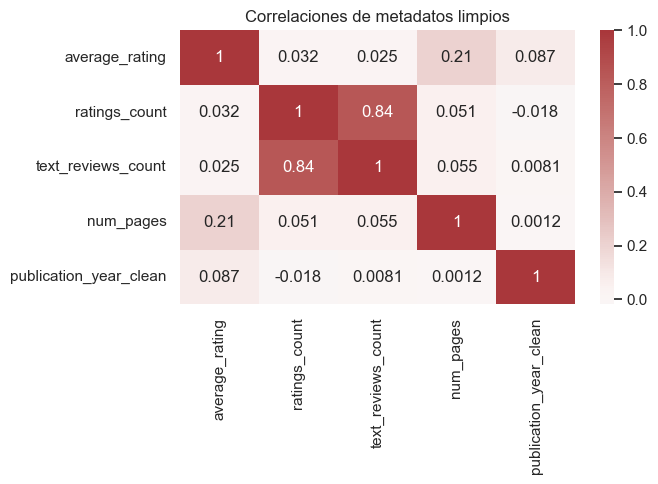

In [25]:
display(artifacts['books_numeric_profile'])
display(artifacts['interactions_numeric_profile'])
display(artifacts['books_outliers'])
display(artifacts['interactions_outliers'])

num_cols = ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year_clean']
corr = books_clean[[c for c in num_cols if c in books_clean.columns]].corr(numeric_only=True)
display(corr)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Correlaciones de metadatos limpios')
plt.tight_layout()
plt.show()

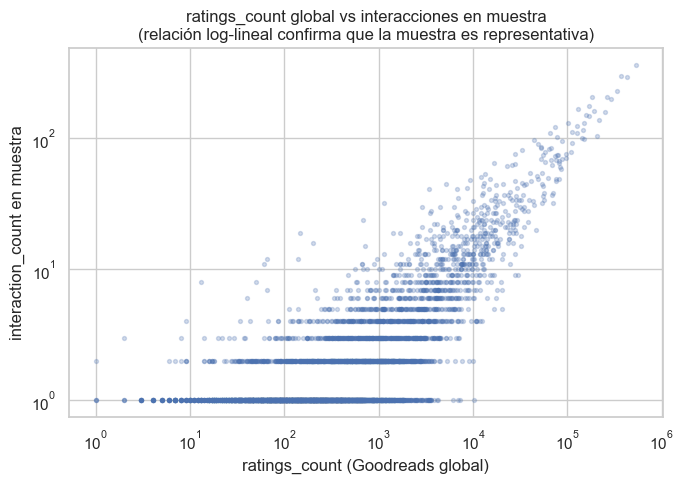

In [26]:
agg_counts = interactions_clean.groupby('book_id').size().rename('sample_interaction_count').reset_index()
merged_counts = books_clean.merge(agg_counts, on='book_id', how='left')

sample_m = merged_counts[['ratings_count', 'sample_interaction_count']].dropna().sample(min(5000, len(merged_counts)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample_m['ratings_count'], sample_m['sample_interaction_count'], alpha=0.25, s=8)
ax.set_xlabel('ratings_count (Goodreads global)')
ax.set_ylabel('interaction_count en muestra')
ax.set_title('ratings_count global vs interacciones en muestra\n(relación log-lineal confirma que la muestra es representativa)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 12. Duplicados y cardinalidad

Se mide la tasa de duplicados antes de deduplicar. `work_id` duplicado es esperable: es el mismo libro en múltiples ediciones.

In [27]:
display(artifacts['duplicates'])

,key,duplicates,records
0,books.book_id,0,50000
1,books.work_id,13430,50000
2,interactions.review_id,0,250000
3,interactions.user_id_book_id,0,250000


## 15. Resumen específico de categoría: Fantasy & Paranormal

Fantasy es el género de ficción serializada por excelencia. Los hallazgos esperados para esta categoría son:
- **Alta tasa de series**: la narrativa de worldbuilding extendido favorece sagas largas
- **Sub-géneros bien definidos**: `urban-fantasy`, `paranormal-romance`, `young-adult` son clusters claramente separables vía shelves
- **Sesgo de rating optimista**: los lectores de Fantasy son comunidad comprometida con sus autores favoritos
- **Colaboraciones de rol**: más traductores/ilustradores que en géneros de no-ficción

In [33]:
ser_s = series_artifacts['summary']
dur_stats = duration_artifacts['duration_stats']
dur_median = dur_stats[dur_stats['stat'] == 'median']['value'].values[0] if len(dur_stats) > 0 else float('nan')

ra_df = eng_artifacts['rating_agreement'].dropna()
rating_corr = ra_df[['average_rating', 'mean_user_rating']].corr().iloc[0, 1] if len(ra_df) > 1 else float('nan')

shelf_only_row = eng_artifacts['engagement_modes'][eng_artifacts['engagement_modes']['mode'] == 'shelf_only']
shelf_only_pct = shelf_only_row['pct'].values[0] if len(shelf_only_row) > 0 else float('nan')

top_shelf = shelf_artifacts['top_shelf_names']['shelf_name'].iloc[0] if len(shelf_artifacts['top_shelf_names']) > 0 else 'N/A'

print('=== RESUMEN FANTASY & PARANORMAL ===')
print(f"Libros en serie:                  {ser_s['pct_in_series']:.1%}")
print(f"Duración mediana de lectura:      {dur_median:.0f} días")
print(f"Correlación rating Goodreads/muestra: {rating_corr:.3f}")
print(f"Usuarios solo-shelf:              {shelf_only_pct:.1%} de interacciones")
print(f"Shelf más frecuente:              '{top_shelf}'")
print(f"Shelf_only/hype vs compra real:   ver relación to-read vs rating en Sección 5")

=== RESUMEN FANTASY & PARANORMAL ===
Libros en serie:                  72.5%
Duración mediana de lectura:      4 días
Correlación rating Goodreads/muestra: 0.337
Usuarios solo-shelf:              48.8% de interacciones
Shelf más frecuente:              'to-read'
Shelf_only/hype vs compra real:   ver relación to-read vs rating en Sección 5


## 16. Conclusiones e Insights Clave

Basado en el análisis exploratorio de la muestra de **Fantasy & Paranormal**, se extraen las siguientes observaciones relevantes para el diseño del sistema de recomendación y modelos predictivos:

1.  **Dominancia de Sagas (72.5%)**: La gran mayoría de los libros pertenecen a una serie. Esto implica que el "Series ID" es una feature crítica; los usuarios que consumen un tomo tienden a buscar los siguientes, y el sistema debe ser capaz de manejar la secuencia lógica de lectura.
2.  **Hype vs. Consumo Real (48.8% solo-shelf)**: Casi la mitad de las interacciones son puramente administrativas (añadir a `to-read`). Aunque es un indicador de **demanda futura** útil para mitigar el *cold-start* de libros nuevos y modelar intención de popularidad, es una señal débil de calidad o satisfacción final.
3.  **Velocidad de Consumo (Mediana de 4 días)**: La duración de lectura es sorprendentemente corta para el género, lo que sugiere un consumo intensivo (binge-reading) típico de nichos fans de fantasía urbana o paranormal romance.
4.  **Acuerdo de Rating Moderado (r = 0.34)**: La correlación entre el promedio global de Goodreads y nuestra muestra es positiva pero moderada. Esto indica que las preferencias en este sub-género pueden ser muy polarizadas o que la muestra captura nichos específicos que no siempre coinciden con el "mainstream" de la plataforma.
5.  **Depuración de Features**: El análisis confirma que campos como `country_code` (varianza nula) y el `publication_year` crudo (outliers extremos) deben descartarse o reemplazarse por versiones limpias. Asimismo, el `ISBN` se descarta como feature de entrenamiento por su alta tasa de missingness y duplicidad, reservándose únicamente como posible llave de enlace con APIs externas.

Este perfil sugiere que un modelo de filtrado colaborativo se beneficiaría enormemente de incluir el estado de la serie y separar las señales de "interés" (`to-read`) de las de "satisfacción" (ratings explícitos).